# Exploratory Data Analysis: Netflix Content Expansion (US vs Asia)

**Objectives:**
- To analyze and compare the production growth trends of Netflix movies and TV shows between the United States and key Asian regions (Taiwan, South Korea, Japan) during the last 5 years of the dataset's coverage.
- To compare distribution of the content types (Movies vs. TV Shows) produced by each region

**Group Members:**
- 吳欣梅 Cindy Cecilia Santoso 41475040h@ntnu.edu.tw
- 鄭秀愛 Amadea Zoie Sardian 41443117s@ntnu.edu.tw
- 劉美麗 Cailyn Fendi Suryadi 41451022s@ntnu.edu.tw

## Pseudocode & Algorithm

1. **Initialize:** Load the Netflix dataset into a dataframe.
2. **Determine Range:** Find the maximum `release_year` in the dataset to set the 5-year window.
3. **Filter Data:** Keep only rows where `release_year` falls within the 5-year window.
4. **Categorize (If-Else Logic):**
   - Read each row in the dataset.
   - `IF` the `country` column contains "United States", categorize as "US Production".
   - `ELSE IF` the `country` column contains "Taiwan", "South Korea", or "Japan", categorize as "Asian Production".
5. **Aggregate for Visualization 1:** Count the total productions grouped by year and region for the trend chart.
6. **Aggregate for Visualization 2:** Count productions grouped by region and content type (Movie/TV Show) to analyze distribution.
7. **Output:** Plot a line chart for production growth and a grouped bar chart for content type comparison.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

file_name = 'netflix_titles.csv'

df = pd.read_csv(file_name)

df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [ ]:
max_year = df['release_year'].max()
print(f"Newest year in the dataset: {max_year}")
print(f"5-year span analyzed: {max_year - 4} until {max_year}\n")

df_recent = df[(df['release_year'] >= max_year - 4) & (df['release_year'] <= max_year)]

def categorize_region(country_data):
    country_str = str(country_data)

    if 'United States' in country_str:
        return 'US Production'
    elif 'Taiwan' in country_str or 'South Korea' in country_str or 'Japan' in country_str:
        return 'Asian Production'
    else:
        return 'Other'

df_recent = df_recent.copy()
df_recent['region'] = df_recent['country'].apply(categorize_region)

df_final = df_recent[df_recent['region'] != 'Other']

df_final[['title', 'country', 'release_year', 'region']].head(10)

Newest year in the dataset: 2021
5-year span analyzed: 2017 until 2021



,title,country,release_year,region
0,Dick Johnson Is Dead,United States,2020,US Production
9,The Starling,United States,2021,US Production
15,Dear White People,United States,2021,US Production
38,Birth of the Dragon,"China, Canada, United States",2017,US Production
40,He-Man and the Masters of the Universe,United States,2021,US Production
55,Nailed It,United States,2021,US Production
81,Kate,United States,2021,US Production
82,Lucifer,United States,2021,US Production
90,Paradise Hills,"Spain, United States",2019,US Production
94,Show Dogs,"United Kingdom, United States",2018,US Production


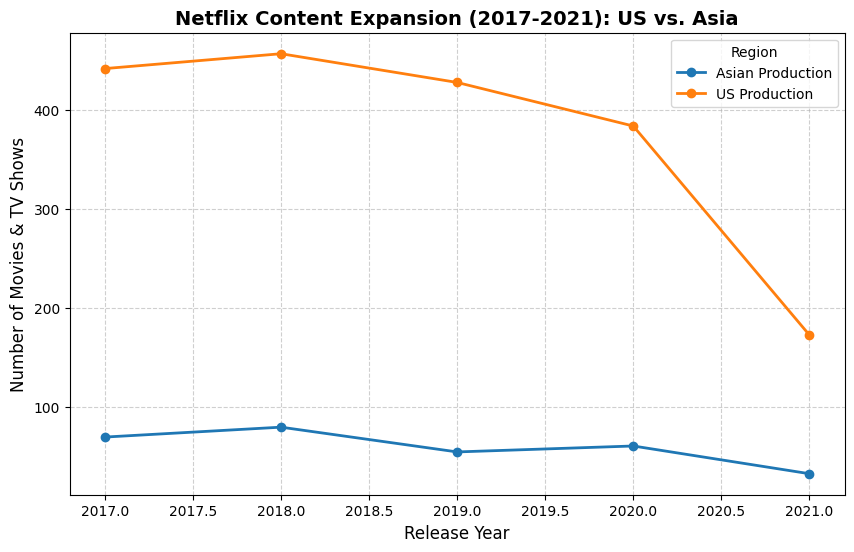

In [14]:
trend_data = df_final.groupby(['release_year', 'region']).size().unstack()

plt.figure(figsize=(10, 6))

trend_data.plot(kind='line', marker='o', linewidth=2, ax=plt.gca())

plt.title('Netflix Content Expansion (2017-2021): US vs. Asia', fontsize=14, fontweight='bold')
plt.xlabel('Release Year', fontsize=12)
plt.ylabel('Number of Movies & TV Shows', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Region')

plt.show()

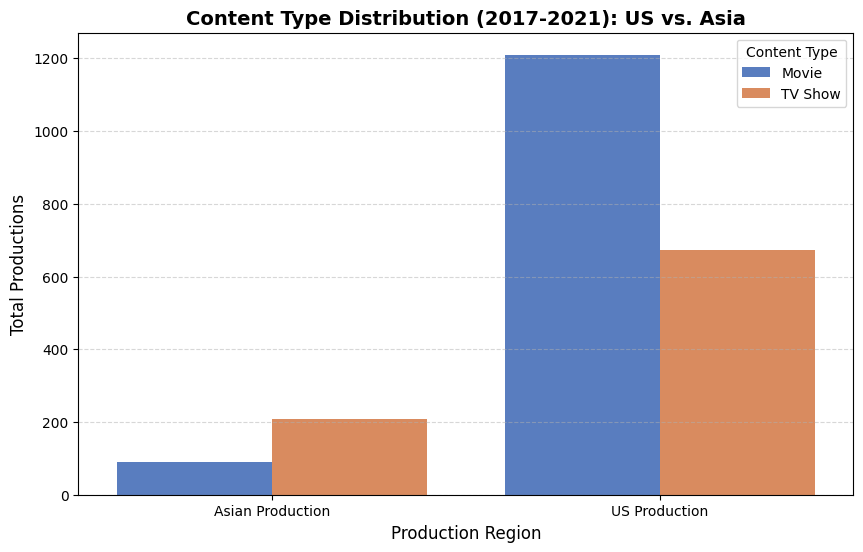

In [13]:
viz2_data = df_final.groupby(['region', 'type']).size().reset_index(name='count')

plt.figure(figsize=(10, 6))

sns.barplot(x='region', y='count', hue='type', data=viz2_data, palette='muted')

plt.title('Content Type Distribution (2017-2021): US vs. Asia', fontsize=14, fontweight='bold')
plt.xlabel('Production Region', fontsize=12)
plt.ylabel('Total Productions', fontsize=12)
plt.legend(title='Content Type')
plt.grid(axis='y', linestyle='--', alpha=0.5)